Validation Set Metrics:
Accuracy: 0.999147079242289
Confusion Matrix:
[[   305      0      0      0     84      0      0]
 [     0   1823      0      0      1      0      0]
 [     0      0  25658      0      6      0      0]
 [     0      0      0  38525     11      7      2]
 [    22      1      4     58 418885    213      2]
 [     0      0      0      5      4  18091      2]
 [     0      0      0      2      6      0    433]]
Precision: 0.9863405504631334
Recall: 0.9661852649690443
F1 Score: 0.9753379636324401


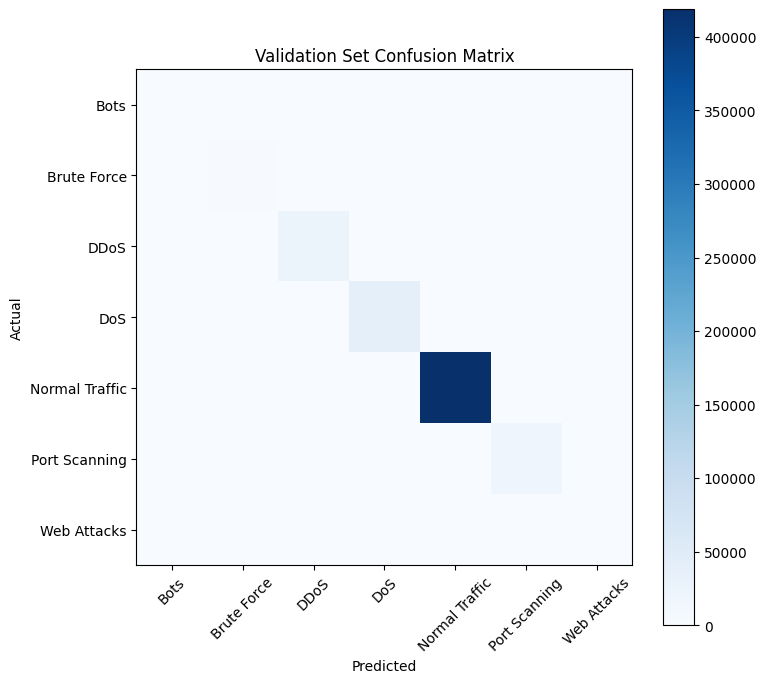

Test Set Metrics:
Accuracy: 0.9991212950088366
Confusion Matrix:
[[   292      0      0      0     92      0      0]
 [     0   1820      0      0      1      0      0]
 [     0      0  25670      0      5      0      0]
 [     0      0      0  38893     14      2      3]
 [    31      0      2     58 418389    215      2]
 [     0      0      0      5      3  18210      1]
 [     0      0      0      0      9      0    434]]
Precision: 0.9823744005791076
Recall: 0.962519837465529
F1 Score: 0.9715558234221117


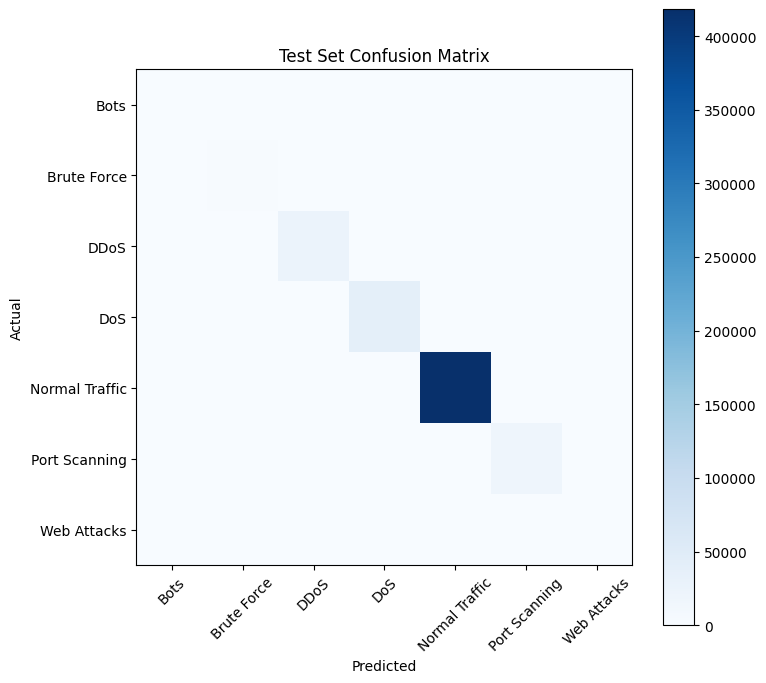

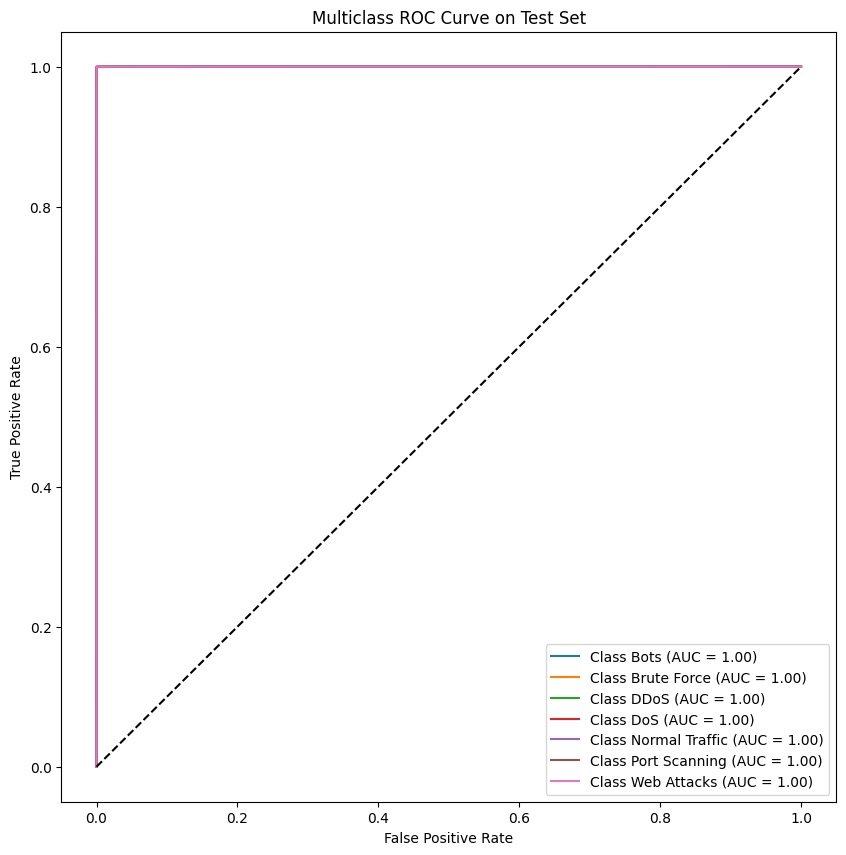

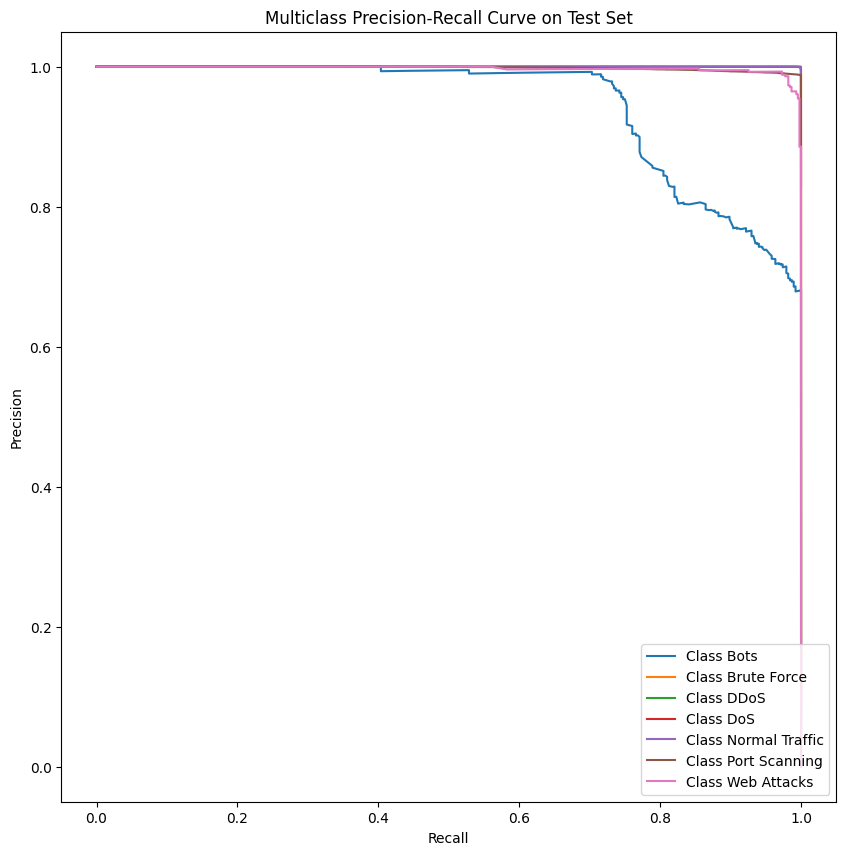

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

# Load the dataset (replace 'path_to_dataset.csv' with the actual path to your CICIDS 2017 dataset)
data = pd.read_csv('D:\datasets\cicids 2017 cleaned and preprocessed\cicids2017_cleaned.csv')

# Preprocess the data (adjust column names and preprocessing as per your dataset)
X = data.drop('Attack Type', axis=1)  # Features
y = data['Attack Type']  # Target (string labels)

# Encode string labels into integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Get the number of unique classes
num_classes = len(np.unique(y_encoded))

# Split the data into training, validation, and testing sets (60% train, 20% validation, 20% test)
# The dataset is first split into a training/validation set (X_train_val, y_train_val) and a test set (X_test, y_test).
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
# The training/validation set is then further split into a training set (X_train, y_train) and a validation set (X_val, y_val). 
# The sizes are configured such that 60% of the data is used for training and validation combined (with a further split of that into training and validation), and 20% is reserved for testing.
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2

# Initialize and train the XGBoost classifier for multiclass classification
model = XGBClassifier(objective='multi:softprob', num_class=num_classes, random_state=42)
model.fit(X_train, y_train)

# Validate the model on the validation set
y_val_pred = model.predict(X_val)
y_val_pred_proba = model.predict_proba(X_val)

# Calculate evaluation metrics for validation set
val_accuracy = accuracy_score(y_val, y_val_pred)
val_conf_matrix = confusion_matrix(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred, average='macro')
val_recall = recall_score(y_val, y_val_pred, average='macro')
val_f1 = f1_score(y_val, y_val_pred, average='macro')

print("Validation Set Metrics:")
print(f"Accuracy: {val_accuracy}")
print(f"Confusion Matrix:\n{val_conf_matrix}")
print(f"Precision: {val_precision}")
print(f"Recall: {val_recall}")
print(f"F1 Score: {val_f1}")

# Plot confusion matrix for validation set
plt.figure(figsize=(8, 8))
plt.imshow(val_conf_matrix, cmap='Blues', interpolation='nearest')
plt.title('Validation Set Confusion Matrix')
plt.colorbar()
plt.xticks(np.arange(num_classes), label_encoder.classes_, rotation=45)
plt.yticks(np.arange(num_classes), label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Test the model on the testing set
y_test_pred = model.predict(X_test)
y_test_pred_proba = model.predict_proba(X_test)

# Calculate evaluation metrics for testing set
test_accuracy = accuracy_score(y_test, y_test_pred)
test_conf_matrix = confusion_matrix(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='macro')
test_recall = recall_score(y_test, y_test_pred, average='macro')
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print("Test Set Metrics:")
print(f"Accuracy: {test_accuracy}")
print(f"Confusion Matrix:\n{test_conf_matrix}")
print(f"Precision: {test_precision}")
print(f"Recall: {test_recall}")
print(f"F1 Score: {test_f1}")

# Plot confusion matrix for testing set
plt.figure(figsize=(8, 8))
plt.imshow(test_conf_matrix, cmap='Blues', interpolation='nearest')
plt.title('Test Set Confusion Matrix')
plt.colorbar()
plt.xticks(np.arange(num_classes), label_encoder.classes_, rotation=45)
plt.yticks(np.arange(num_classes), label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot ROC curve (one vs rest approach for each class on test set)
plt.figure(figsize=(10, 10))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_test_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {label_encoder.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve on Test Set')
plt.legend(loc='lower right')
plt.show()

# Plot Precision-Recall curve (one vs rest approach for each class on test set)
plt.figure(figsize=(10, 10))
for i in range(num_classes):
    precision_vals, recall_vals, _ = precision_recall_curve((y_test == i).astype(int), y_test_pred_proba[:, i])
    plt.plot(recall_vals, precision_vals, label=f'Class {label_encoder.classes_[i]}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Multiclass Precision-Recall Curve on Test Set')
plt.legend(loc='lower right')
plt.show()
